# Notebook 1 — Sensor Data Simulation & MQTT Basics — Completed
**DigiHaz Module 7 Topic 4**  
Source: `Digihaz/digihaz-course-materials` → `module_07_iot_sensor_networks/topic_04/notebooks/01_sensor_simulation_mqtt.ipynb`

This completed copy runs the deterministic sensor simulation locally. The public MQTT publication step is represented in **offline/mock mode** because this execution environment has no outbound network access. The JSON message format and topic structure are preserved.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import json
from datetime import datetime, timezone

DURATION_HOURS=48
SAMPLE_RATE_S=60
FAILURE_AT_HOUR=36
np.random.seed(42)
n_samples=int(DURATION_HOURS*3600/SAMPLE_RATE_S)
t_hours=np.arange(n_samples)*SAMPLE_RATE_S/3600
print('Libraries loaded; samples =', n_samples)


Libraries loaded; samples = 2880


## Part 1 — MPU6050 tilt simulation
The source notebook simulates slow creep followed by a failure lurch.


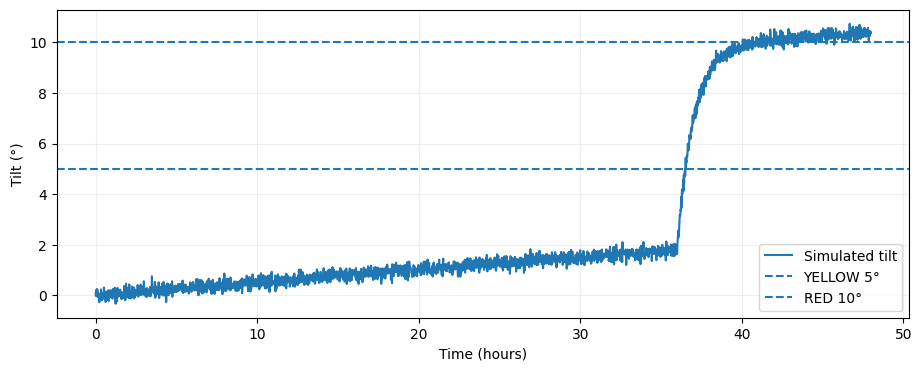

Generated 2880 samples over 48 hours
Max tilt: 10.74° | Final tilt: 10.37°


In [2]:
creep=0.05*t_hours
failure=np.where(t_hours>FAILURE_AT_HOUR,8*(1-np.exp(-(t_hours-FAILURE_AT_HOUR))),0)
noise=np.random.normal(0,0.15,n_samples)
tilt_deg=creep+failure+noise
plt.figure(figsize=(11,4))
plt.plot(t_hours,tilt_deg,label='Simulated tilt')
plt.axhline(5,ls='--',label='YELLOW 5°')
plt.axhline(10,ls='--',label='RED 10°')
plt.xlabel('Time (hours)'); plt.ylabel('Tilt (°)'); plt.legend(); plt.grid(alpha=.2); plt.show()
print(f'Generated {n_samples} samples over {DURATION_HOURS} hours')
print(f'Max tilt: {tilt_deg.max():.2f}° | Final tilt: {tilt_deg[-1]:.2f}°')


## Part 2 — BMP280 pressure + storm trend


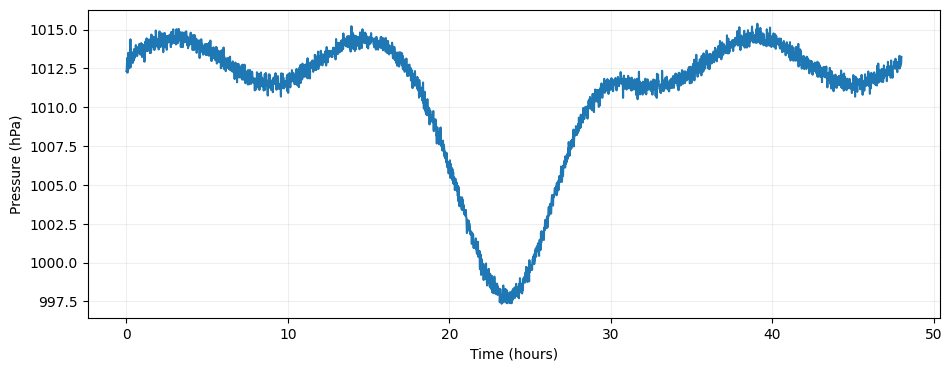

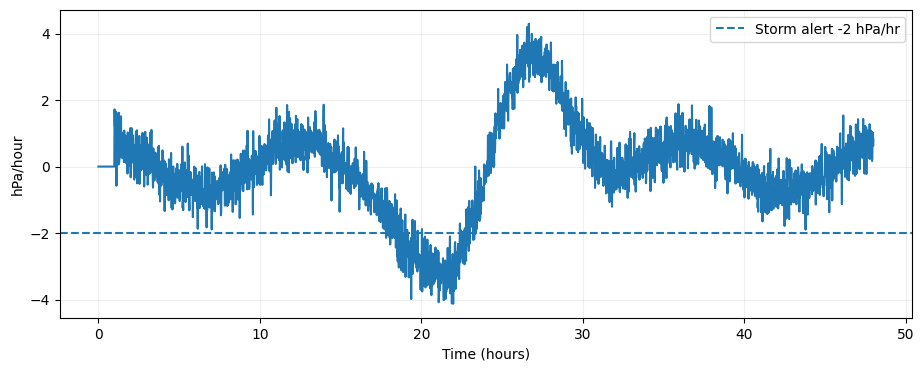

Min pressure: 997.35 hPa | Min trend: -4.13 hPa/hr


In [3]:
pressure_hpa=1013+1.5*np.sin(2*np.pi*t_hours/12)
pressure_hpa += -15*np.exp(-((t_hours-24)/4)**2)
pressure_hpa += np.random.normal(0,0.3,n_samples)
temperature_c=23+5*np.sin(2*np.pi*(t_hours-6)/24)+np.random.normal(0,0.4,n_samples)
pressure_trend=pd.Series(pressure_hpa).diff(60).fillna(0).values
plt.figure(figsize=(11,4)); plt.plot(t_hours,pressure_hpa); plt.xlabel('Time (hours)'); plt.ylabel('Pressure (hPa)'); plt.grid(alpha=.2); plt.show()
plt.figure(figsize=(11,4)); plt.plot(t_hours,pressure_trend); plt.axhline(-2,ls='--',label='Storm alert -2 hPa/hr'); plt.xlabel('Time (hours)'); plt.ylabel('hPa/hour'); plt.legend(); plt.grid(alpha=.2); plt.show()
print(f'Min pressure: {pressure_hpa.min():.2f} hPa | Min trend: {pressure_trend.min():.2f} hPa/hr')


## Part 3 — Soil moisture simulation


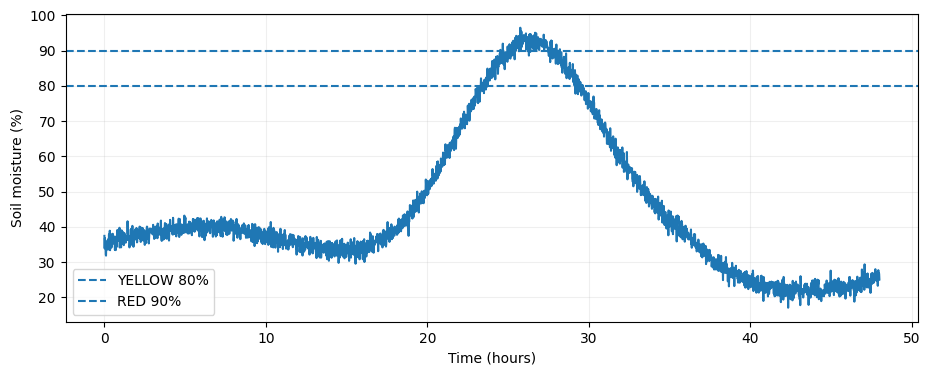

Max soil moisture: 96.49% at hour 25.75


In [4]:
ADC_DRY=3300; ADC_WET=1200
base_moisture=35+5*np.sin(2*np.pi*t_hours/24)
storm_saturation=55*np.exp(-((t_hours-26)/6)**2)
drain=-10*np.where(t_hours>FAILURE_AT_HOUR,1-np.exp(-(t_hours-FAILURE_AT_HOUR)/4),0)
soil_pct=np.clip(base_moisture+storm_saturation+drain+np.random.normal(0,1.5,n_samples),0,100)
soil_raw=ADC_DRY-(soil_pct/100)*(ADC_DRY-ADC_WET)
plt.figure(figsize=(11,4)); plt.plot(t_hours,soil_pct); plt.axhline(80,ls='--',label='YELLOW 80%'); plt.axhline(90,ls='--',label='RED 90%'); plt.xlabel('Time (hours)'); plt.ylabel('Soil moisture (%)'); plt.legend(); plt.grid(alpha=.2); plt.show()
print(f'Max soil moisture: {soil_pct.max():.2f}% at hour {t_hours[np.argmax(soil_pct)]:.2f}')


## Part 4 — Combined threshold logic


In [5]:
alert_state=np.full(n_samples,'GREEN',dtype=object)
alert_state[(tilt_deg>5)&(soil_pct>80)]='YELLOW'
alert_state[(tilt_deg>10)&(soil_pct>90)]='RED'
for level in ['YELLOW','RED']:
    idx=np.where(alert_state==level)[0]
    print(f'First {level}:', 'never triggered' if len(idx)==0 else f'{t_hours[idx[0]]:.2f} h')
storm_idx=np.where(pressure_trend<-2)[0]
first_storm=t_hours[storm_idx[0]] if len(storm_idx) else None
print('First STORM threshold:', None if first_storm is None else round(float(first_storm),2),'h')


First YELLOW: never triggered
First RED: never triggered
First STORM threshold: 17.82 h


## Part 5 — MQTT message format (offline/mock publication)
The source notebook publishes to `test.mosquitto.org`. Here we build the same JSON payloads without making an external network call.


In [6]:
SITE='demo_yueqimin'
TOPIC_PREFIX=f'digihaz/{SITE}'
def build_message(i):
    return {'ts':datetime.now(timezone.utc).isoformat(),'site':SITE,'tilt_deg':round(float(tilt_deg[i]),2),'press_hpa':round(float(pressure_hpa[i]),2),'soil_pct':round(float(soil_pct[i]),1),'alert':alert_state[i],'sim_hour':round(float(t_hours[i]),2)}
for i in list(range(0,n_samples,100))[:10]:
    print(TOPIC_PREFIX+'/all', json.dumps(build_message(i)))


digihaz/demo_yueqimin/all {"ts": "2026-10-01T03:39:43.675752+00:00", "site": "demo_yueqimin", "tilt_deg": 0.07, "press_hpa": 1012.33, "soil_pct": 37.4, "alert": "GREEN", "sim_hour": 0.0}
digihaz/demo_yueqimin/all {"ts": "2026-10-01T03:39:43.675838+00:00", "site": "demo_yueqimin", "tilt_deg": -0.13, "press_hpa": 1014.23, "soil_pct": 36.0, "alert": "GREEN", "sim_hour": 1.67}
digihaz/demo_yueqimin/all {"ts": "2026-10-01T03:39:43.675863+00:00", "site": "demo_yueqimin", "tilt_deg": 0.22, "press_hpa": 1014.84, "soil_pct": 37.8, "alert": "GREEN", "sim_hour": 3.33}
digihaz/demo_yueqimin/all {"ts": "2026-10-01T03:39:43.675881+00:00", "site": "demo_yueqimin", "tilt_deg": 0.13, "press_hpa": 1014.04, "soil_pct": 42.0, "alert": "GREEN", "sim_hour": 5.0}
digihaz/demo_yueqimin/all {"ts": "2026-10-01T03:39:43.675896+00:00", "site": "demo_yueqimin", "tilt_deg": 0.09, "press_hpa": 1012.23, "soil_pct": 40.3, "alert": "GREEN", "sim_hour": 6.67}
digihaz/demo_yueqimin/all {"ts": "2026-10-01T03:39:43.675911+

## Reflection — Completed

1. **Pressure lead time:** The storm trend first crossed -2 hPa/hour at **17.82 h**. This deterministic run produced **no YELLOW/RED landslide alert** because the soil saturation peak and the high-tilt period do not overlap. Therefore a storm-to-landslide-alert lead time is not defined here. In a real EWS, the early pressure signal can still increase sampling, trigger sensor checks, prepare field teams, and move the system into a watch state.
2. **ADC outside calibration:** raw 4000 gives **-33.33%** and raw 800 gives **119.05%** if the linear formula is not clamped. A production function should clamp display values to 0–100% and separately flag out-of-calibration readings.
3. **Public MQTT risks:** no strong authentication/ACLs, plaintext transport on port 1883, and no operational SLA. A field EWS should use a private/managed broker, TLS on 8883, per-device credentials/certificates, ACLs, monitoring, and audit logs.

**Execution observation:** the source narrative suggests a later landslide alert, but the actual deterministic parameter set does not produce one. This is preserved rather than silently changed.
